# Implicit Gradient Flow with $\ell^p$ Distance Penalty

We compute proximal implicit steps
$$
x_{k+1} = \arg\min_x \|x-x_k\|_p^2 + \tau\|x-y\|_2^2,
$$
for several $p$, and compare trajectories toward target point $y$.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

y = np.array([0.9, -0.8])
x0 = np.array([-1.4, 1.2])
tau = 0.35
steps = 45

def grad_lp_sq(v, p):
    a = np.abs(v) + 1e-12
    S = np.sum(a**p)
    return 2 * (S**(2/p - 1)) * (a**(p-2)) * v

def prox_step(xk, p, it=70, lr=0.08):
    x = xk.copy()
    for _ in range(it):
        g = grad_lp_sq(x - xk, p) + 2*tau*(x - y)
        x = x - lr*g
    return x


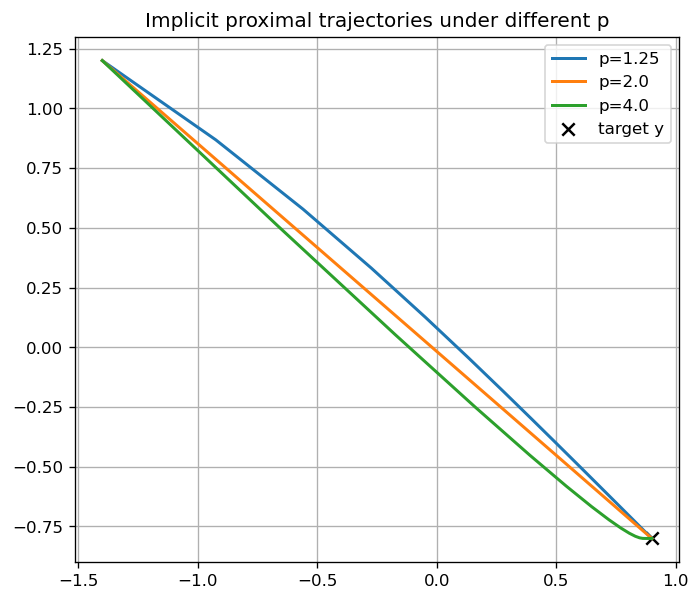

In [2]:
ps = [1.25, 2.0, 4.0]
trajs = []
for p in ps:
    x = x0.copy()
    T = [x.copy()]
    for _ in range(steps):
        x = prox_step(x, p)
        T.append(x.copy())
    trajs.append(np.array(T))

fig, ax = plt.subplots(figsize=(6.5, 5.8))
for p, T in zip(ps, trajs):
    ax.plot(T[:,0], T[:,1], lw=1.8, label=f'p={p}')
ax.scatter([y[0]],[y[1]], c='k', s=55, marker='x', label='target y')
ax.set_aspect('equal')
ax.legend()
ax.set_title('Implicit proximal trajectories under different p')
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()
